
# <span style="color:rgb(213,80,0)">Waveforms</span>

In [1]:
% Unipolar NRZ
clear;
clc;
close all;

% Binary data
bits = [1 0 1 1 0 0 1 0 1 1];

% Amplitude
A = 1;

% Samples per bit
rep_bit = 100;

% Generate Unipolar NRZ waveform
unipolar_nrz = repelem(bits * A, rep_bit)

unipolar_nrz = 1x1000     Columns 1:27
     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     1     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0 


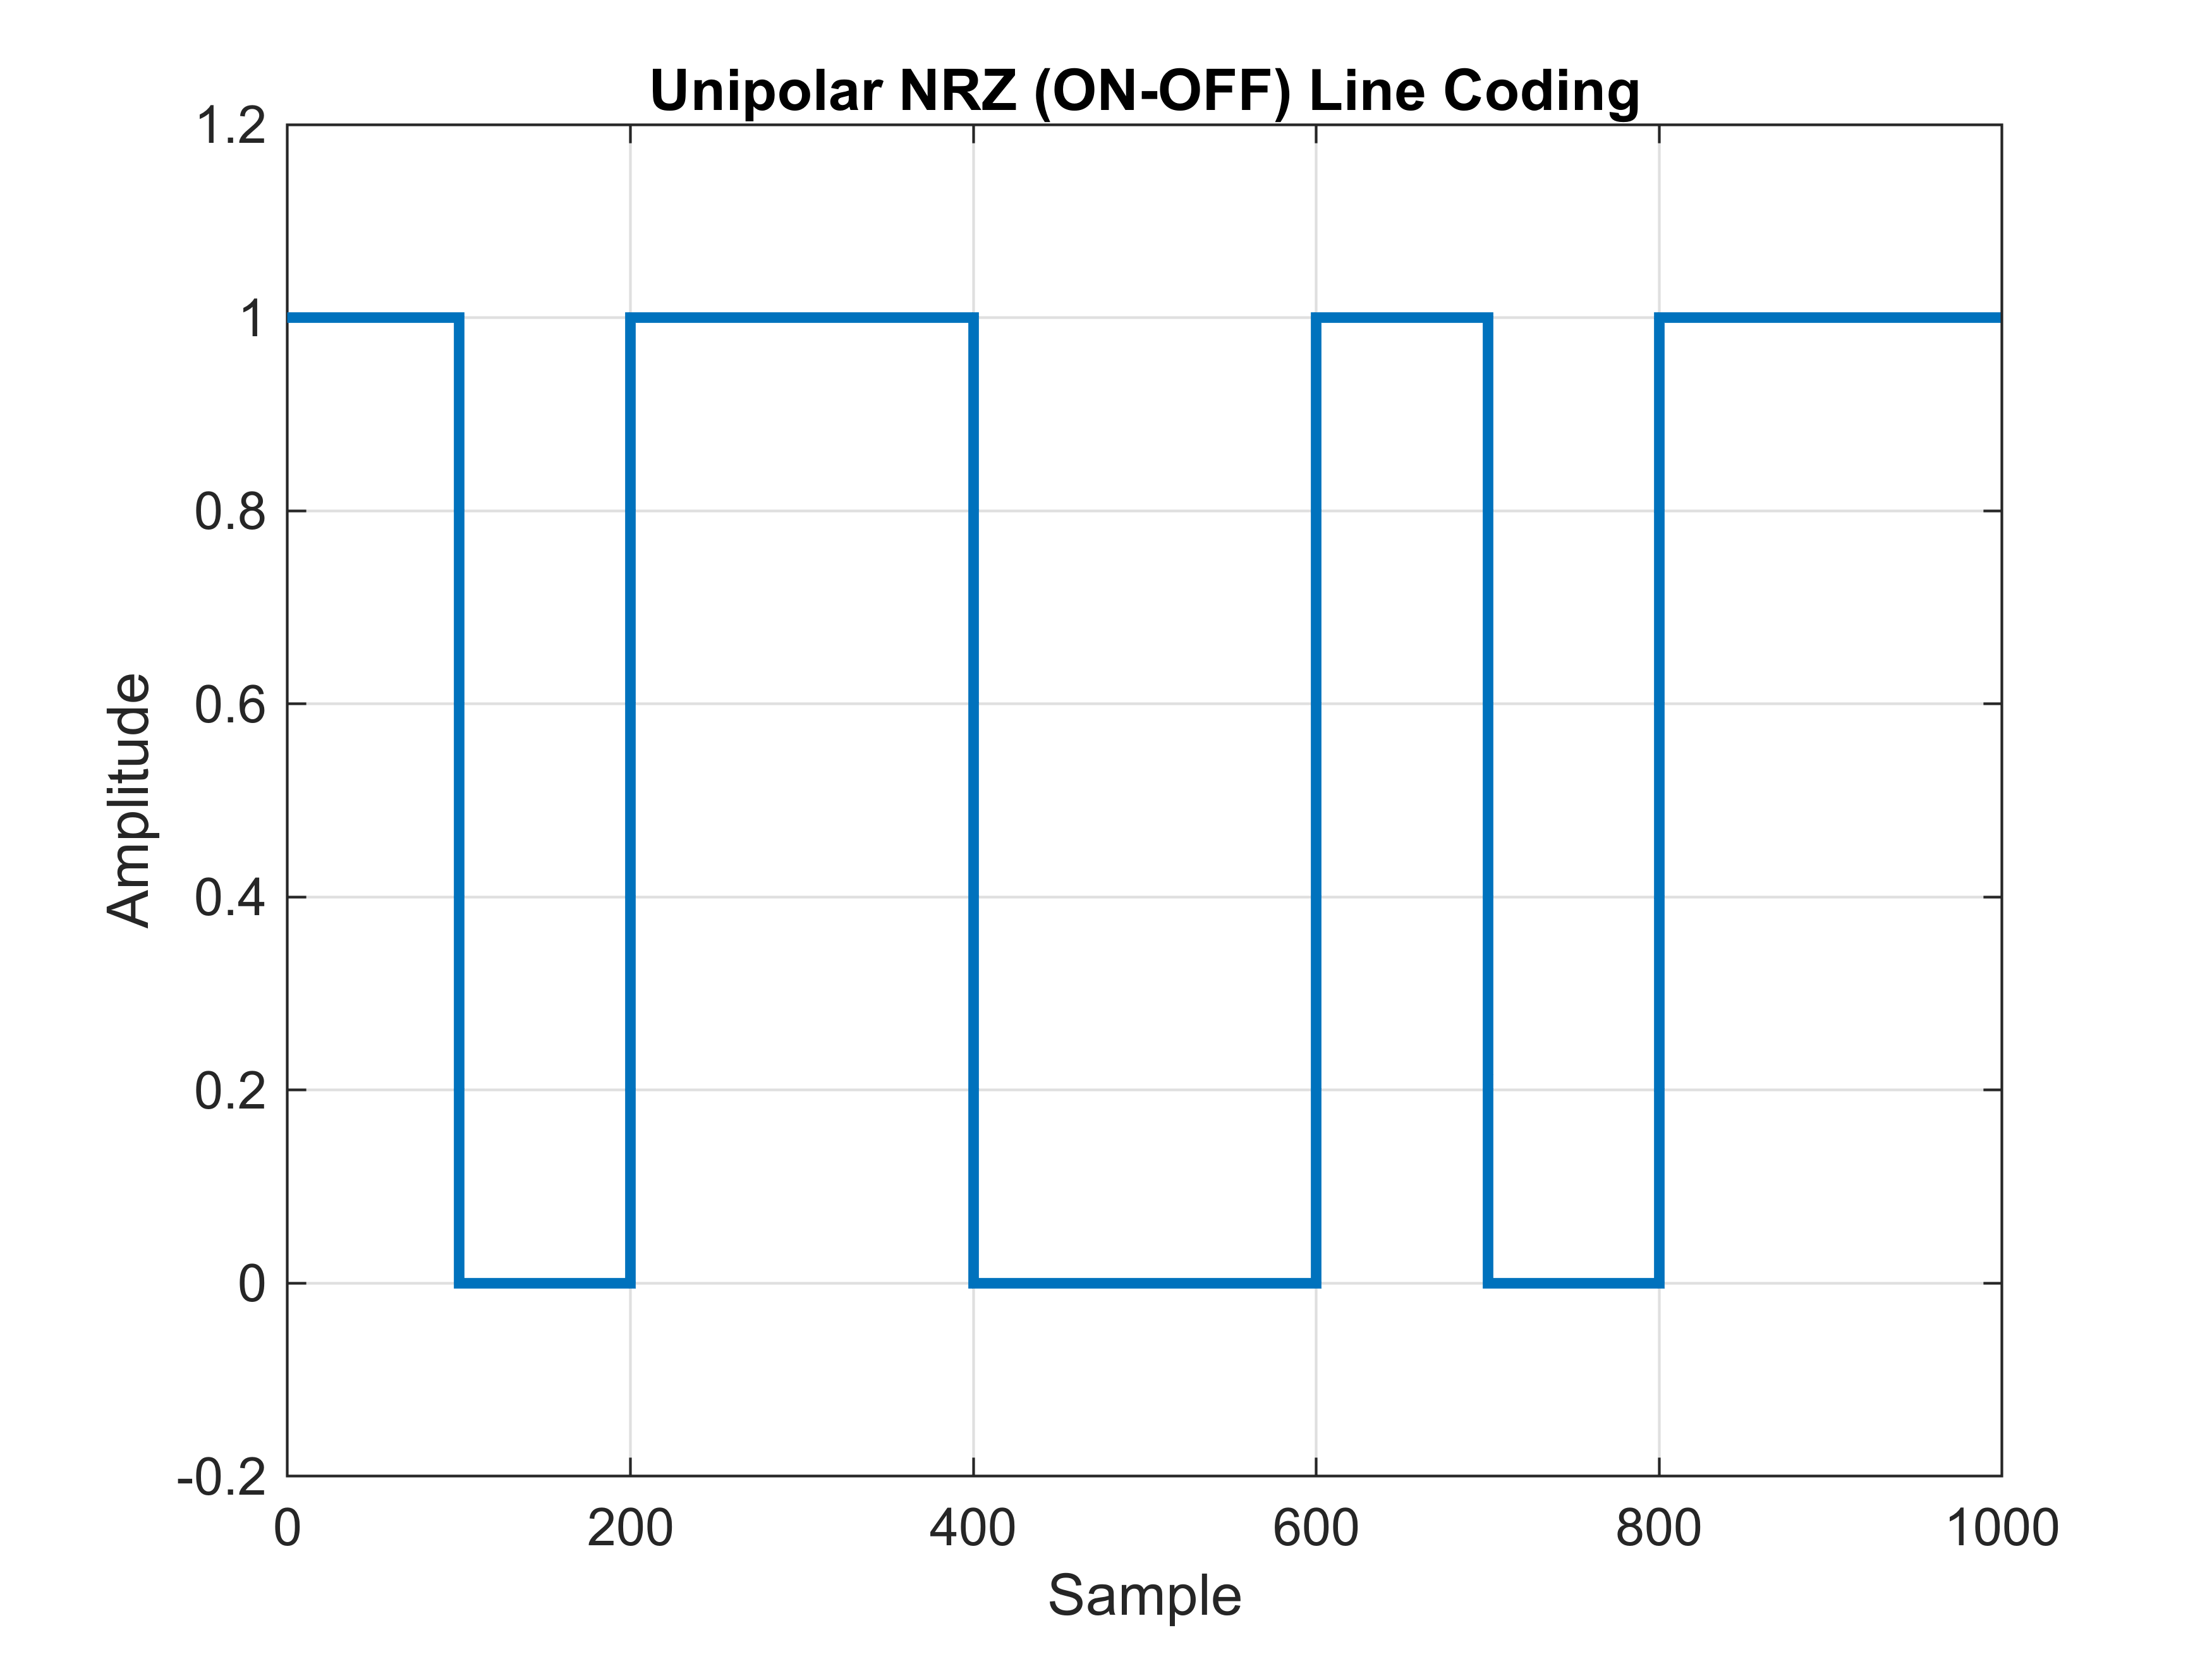

In [2]:
doc repelem;
% Time axis
t = 0:length(unipolar_nrz)-1;

% Plot
figure;

stairs(t, unipolar_nrz, 'LineWidth', 2);
grid on;

xlabel('Sample');
ylabel('Amplitude');
title('Unipolar NRZ (ON-OFF) Line Coding');

ylim([-0.2 1.2]);

## polar NRZ

In [3]:
polar_level = 2*bits -1

polar_level = 1x10    
     1    -1     1     1    -1    -1     1    -1     1     1


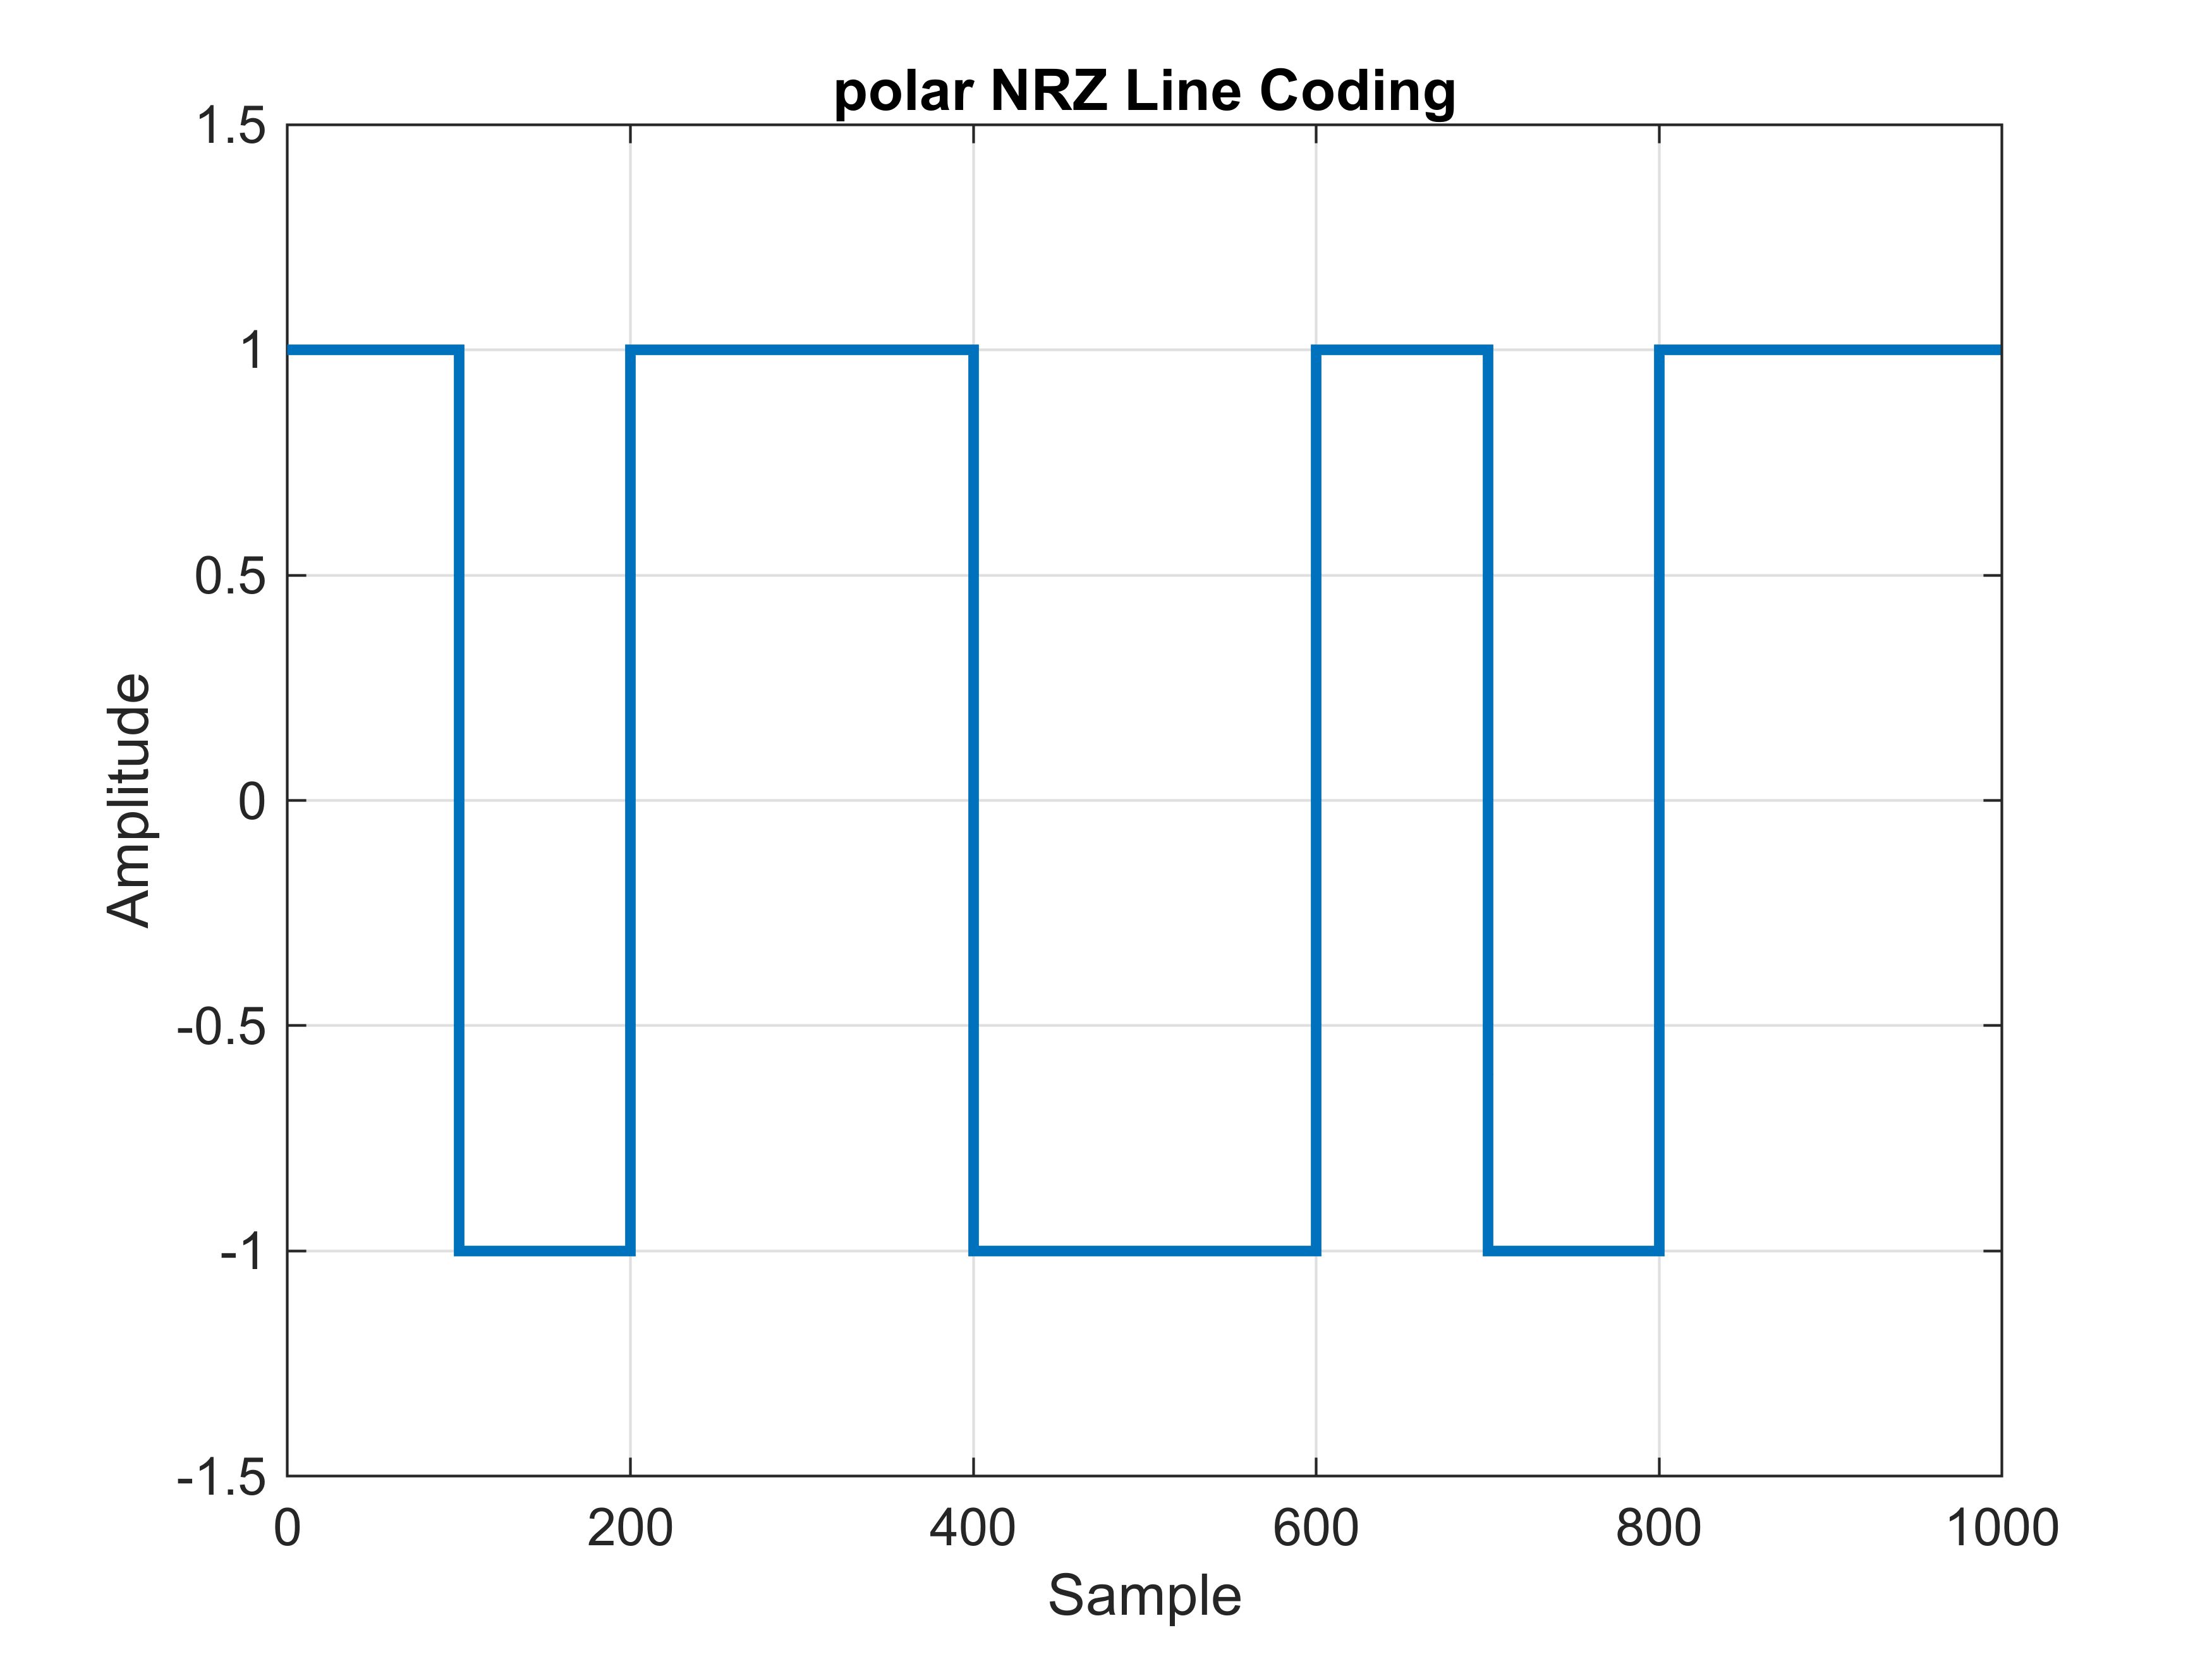

In [4]:

% create waveform
polar_nrz = repelem(A*polar_level, rep_bit);

% Time axis
t = 0:length(polar_nrz)-1;

% Plot
figure;

stairs(t, polar_nrz, 'LineWidth', 2);
grid on;

xlabel('Sample');
ylabel('Amplitude');
title('polar NRZ Line Coding');
ylim([-1.5, 1.5]);

## Bipolar NRZ (AMI \- Alternative mark inversion)


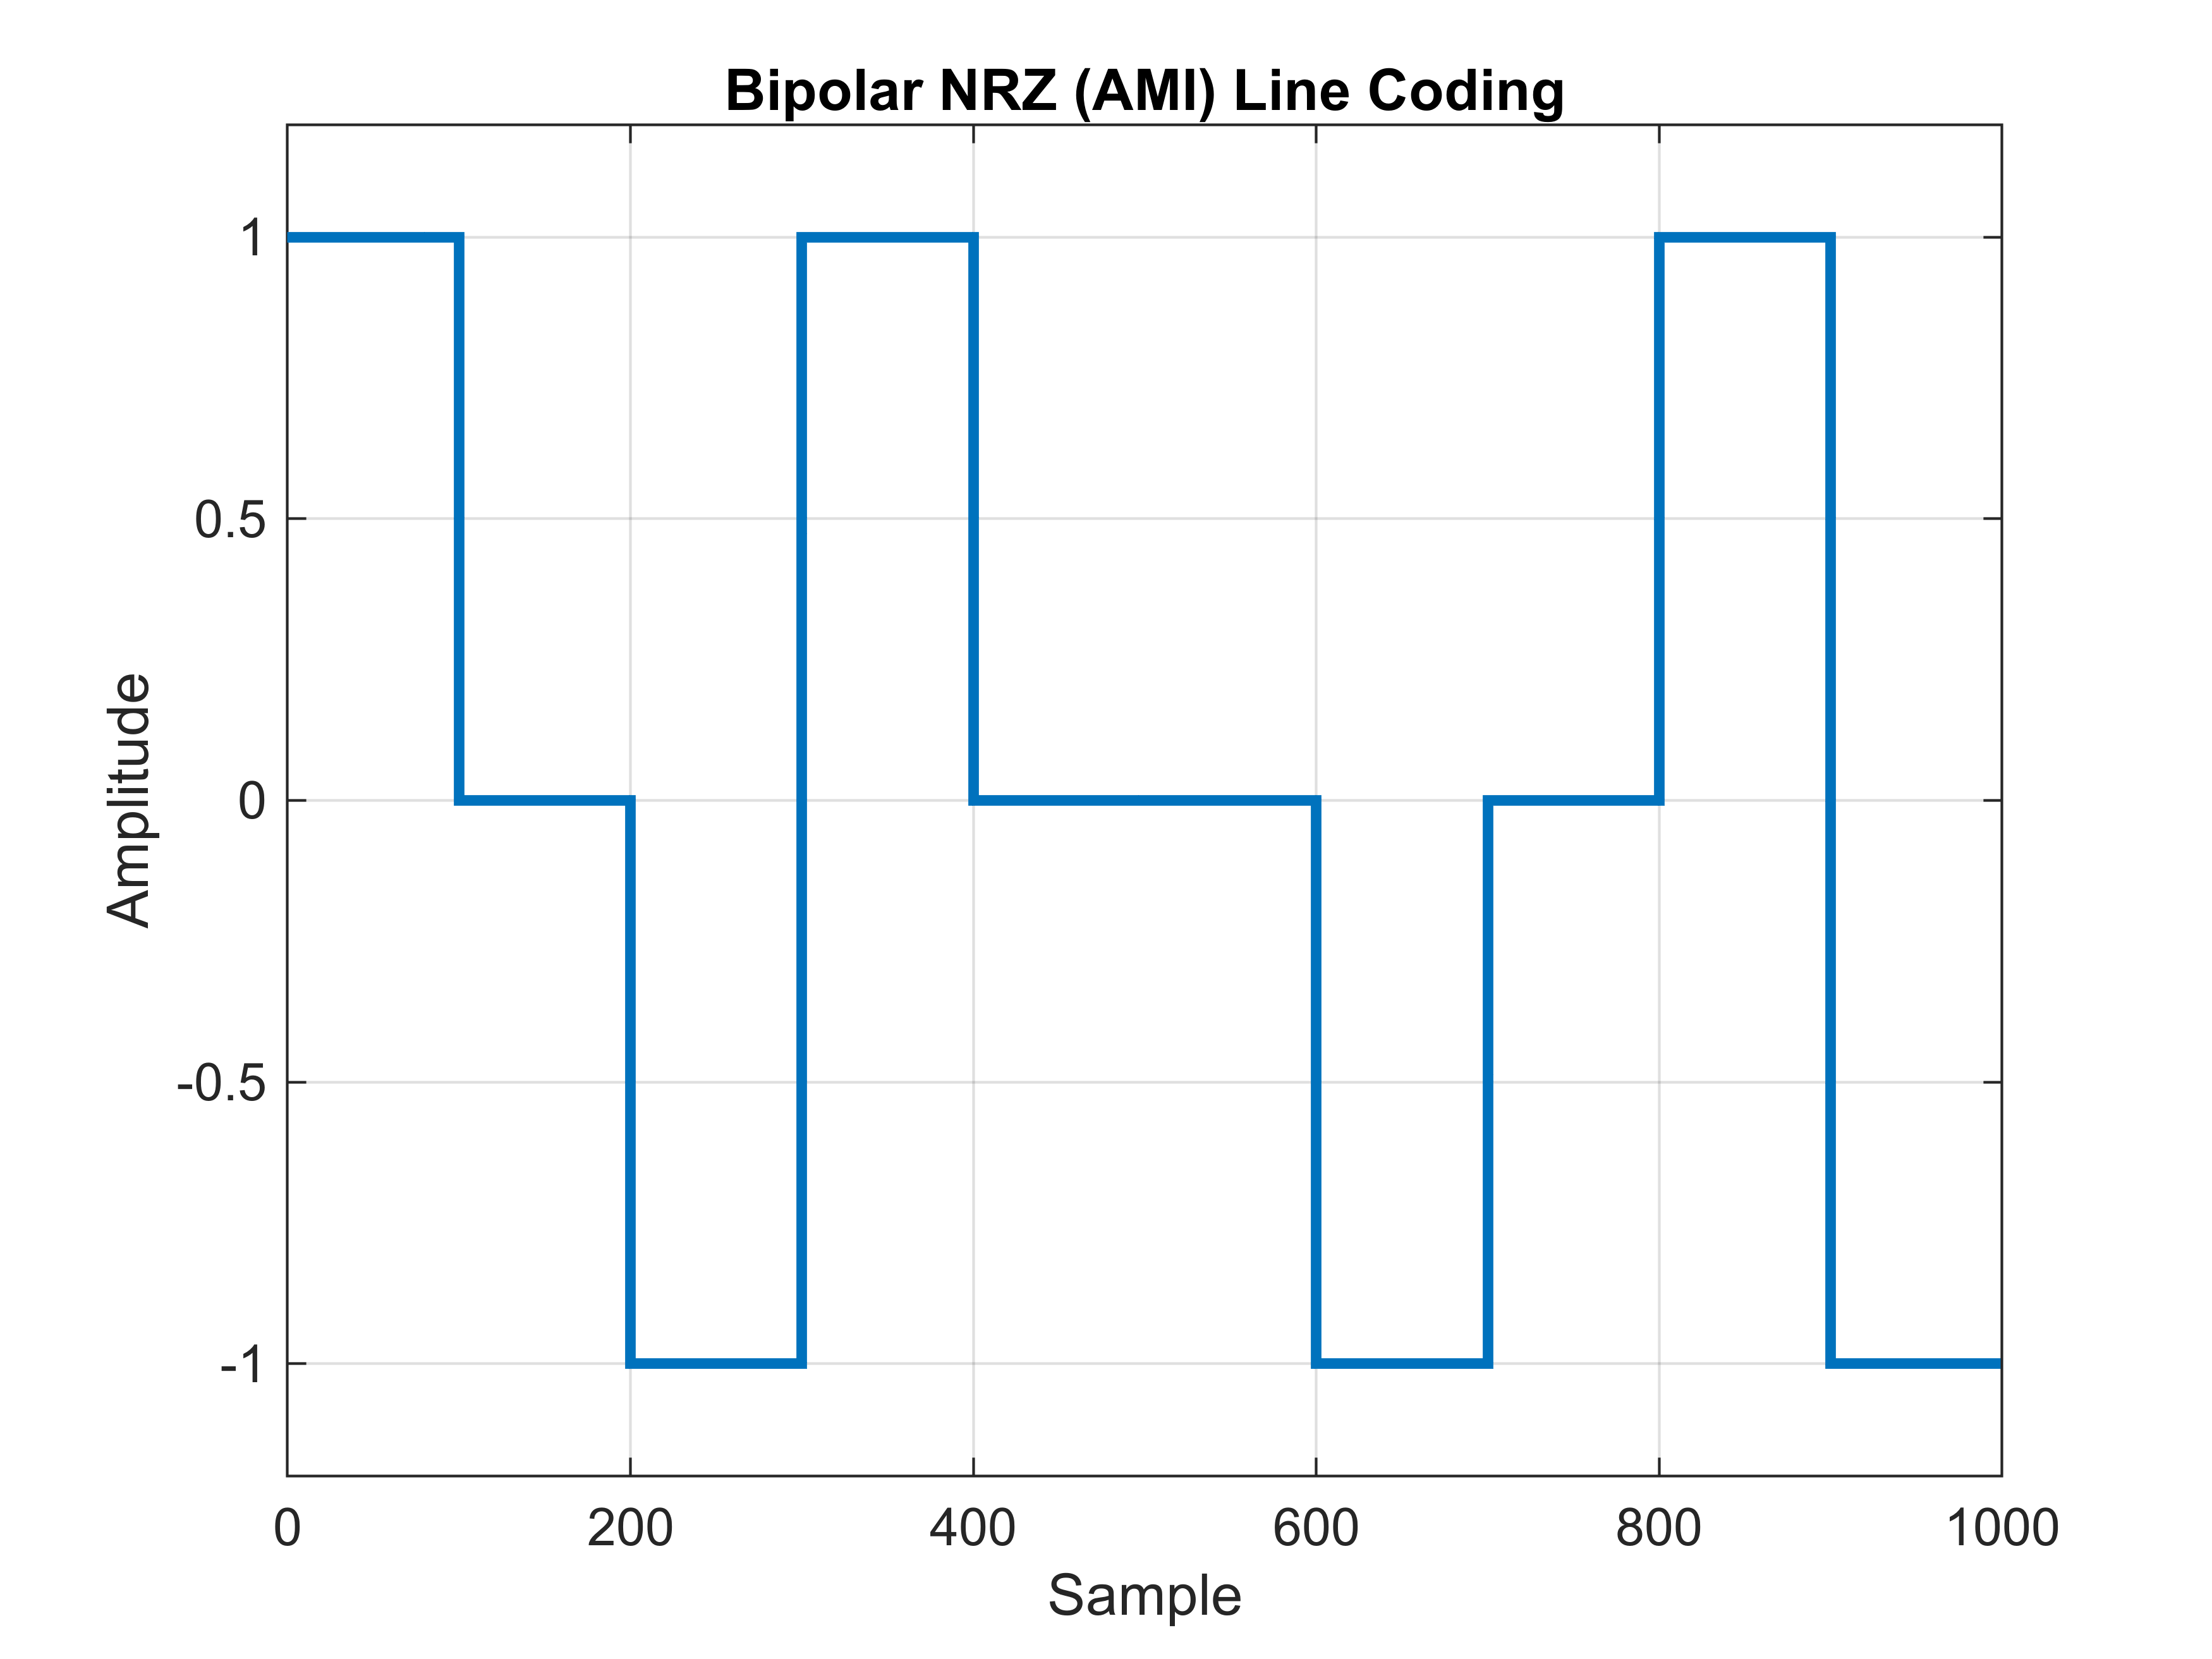

In [5]:
% AMI generation
ami_levels = zeros(size(bits));

polarity = A;

for k = 1: length(bits)
    if bits(k)==1
        ami_levels(k) = polarity;
        polarity = -polarity;
    else
        ami_levels(k) = 0;
    end
end

% Expand each bit into samples
ami_signal = repelem(ami_levels, rep_bit);

% Time axis
t = 0:length(ami_signal)-1;

% Plot
figure;

stairs(t, ami_signal, 'LineWidth', 2);
grid on;

xlabel('Sample');
ylabel('Amplitude');
title('Bipolar NRZ (AMI) Line Coding');

ylim([-1.2 1.2]);


## RZ


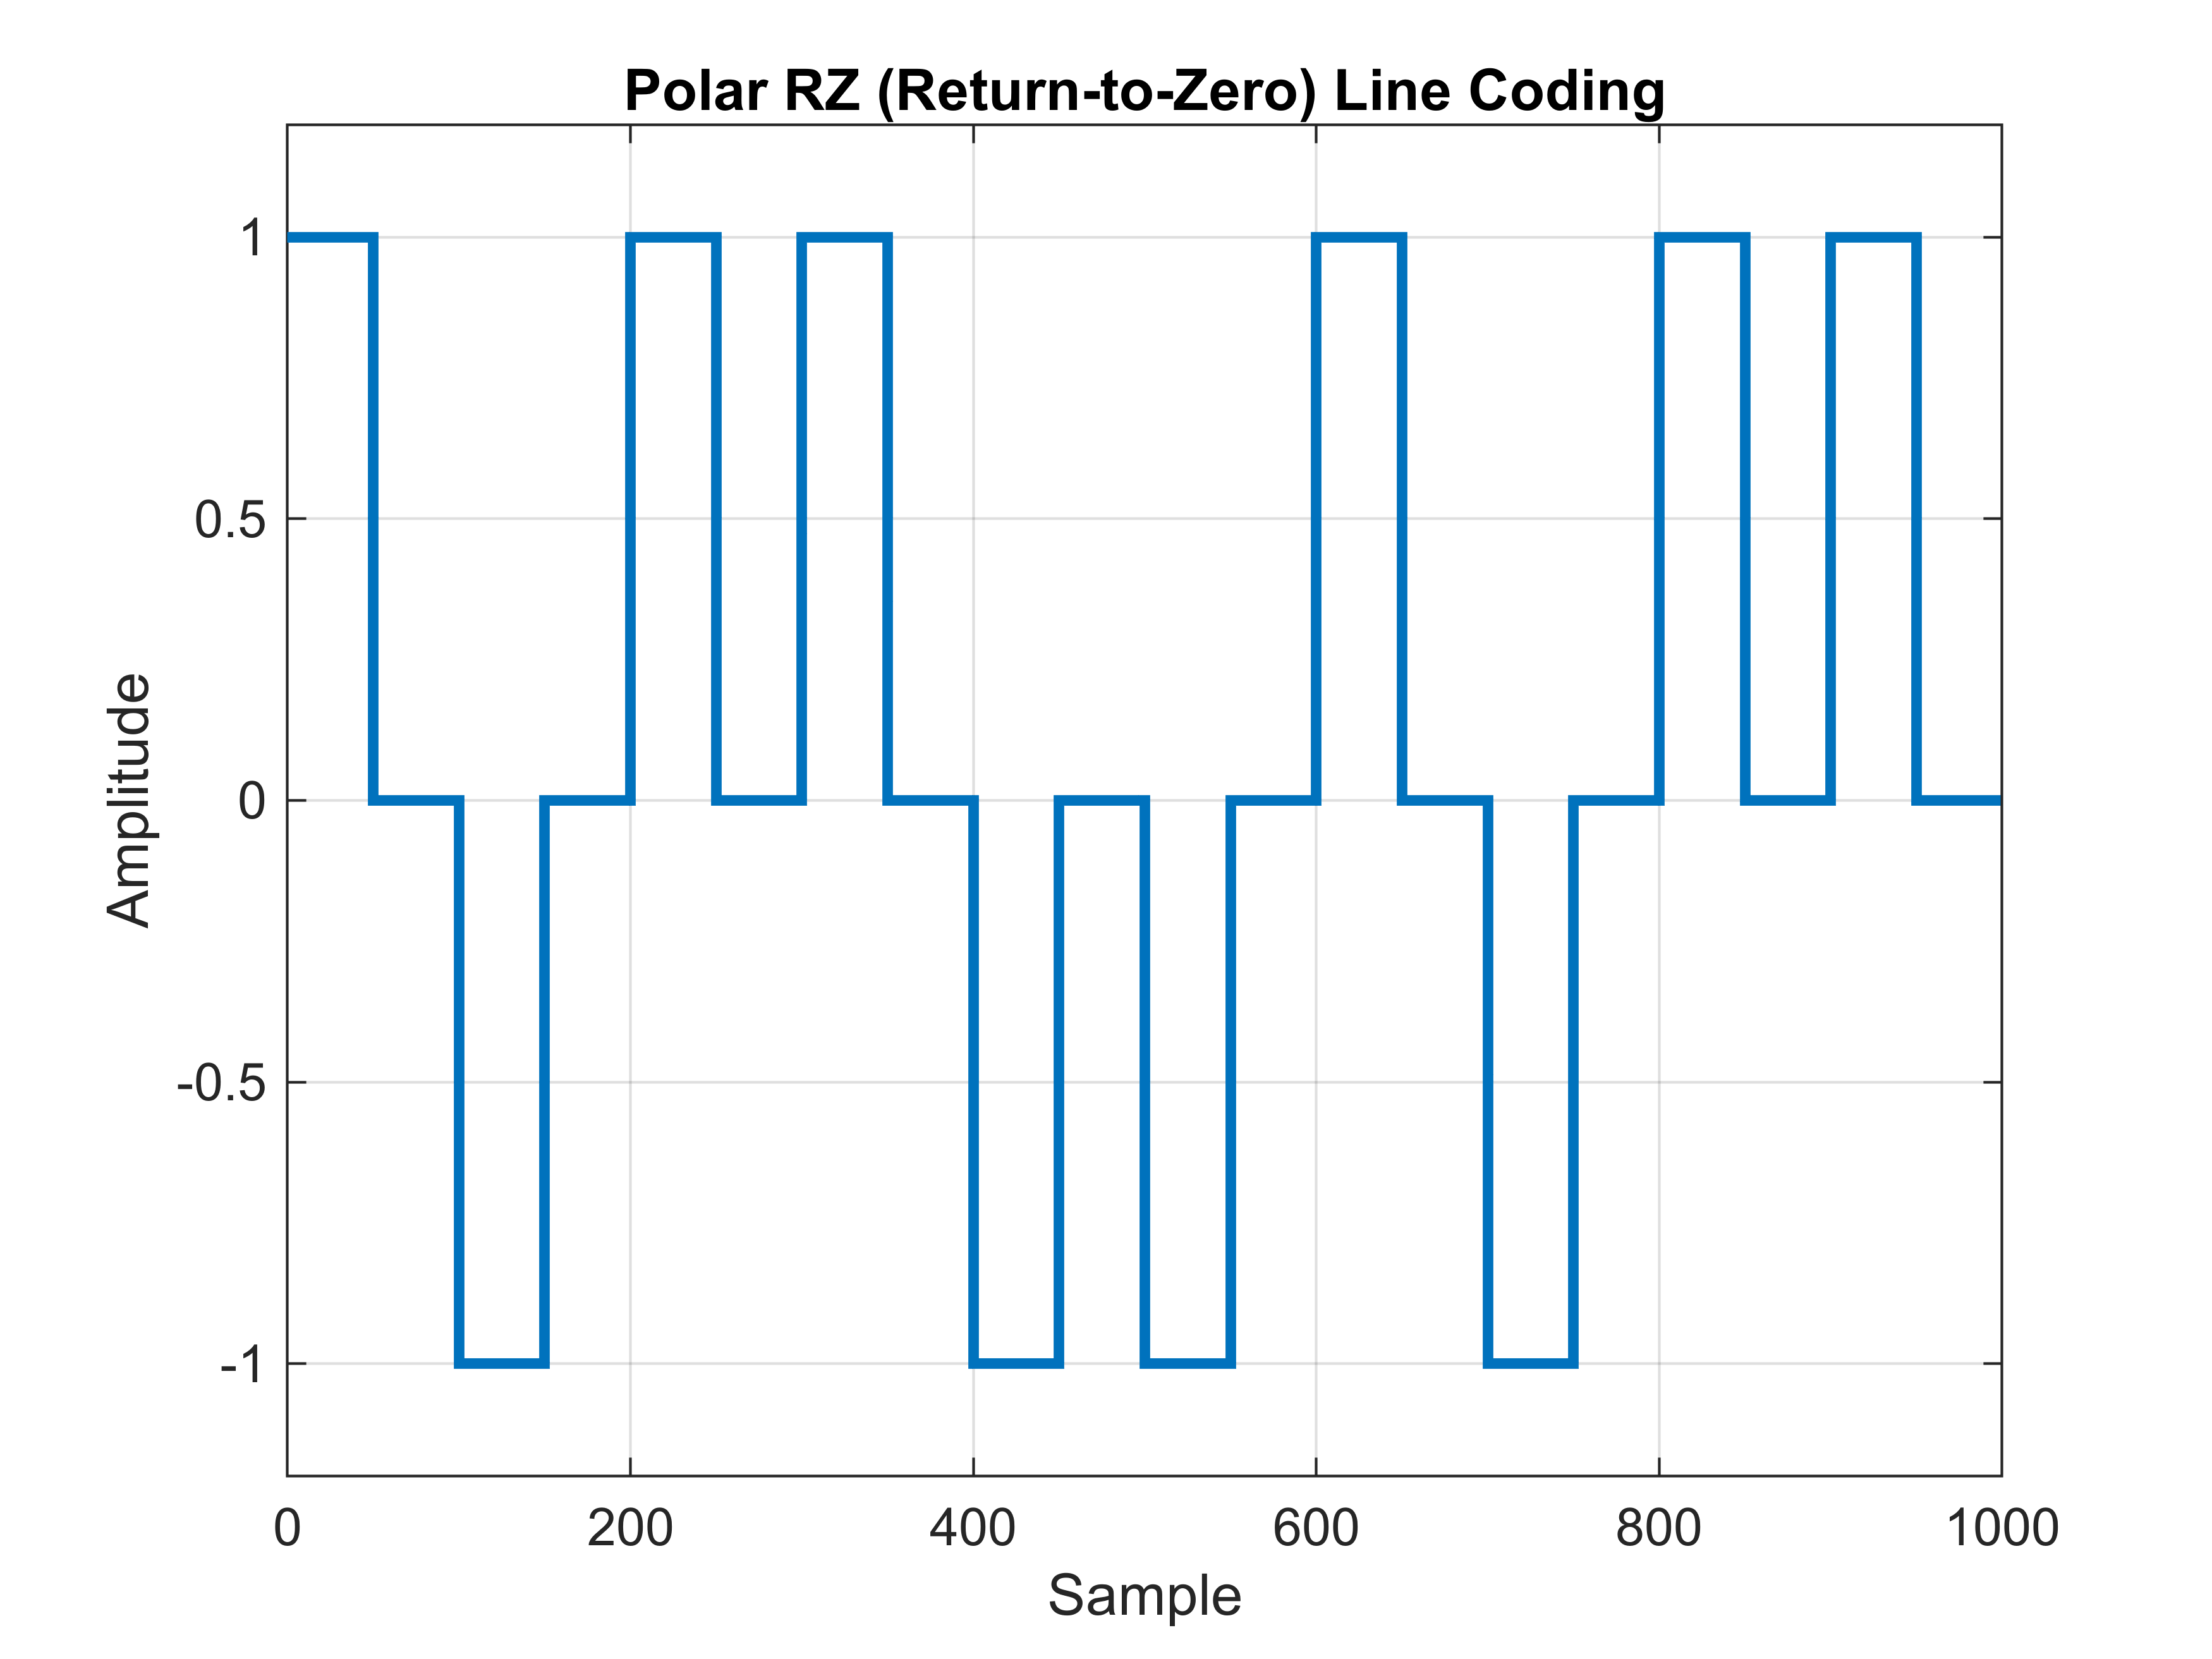

In [6]:
spb = 100;
% Samples during first half of bit
half = spb/2;

% Generate RZ waveform
rz_signal = [];

for k = 1:length(bits)

    if bits(k) == 1
        level = A;
    else
        level = -A;
    end

    % First half: signal level
    first_half = level * ones(1, half);

    % Second half: return to zero
    second_half = zeros(1, half);

    % Combine
    rz_signal = [rz_signal first_half second_half];

end

% Time axis
t = 0:length(rz_signal)-1;

% Plot
figure;

stairs(t, rz_signal, 'LineWidth', 2);
grid on;

xlabel('Sample');
ylabel('Amplitude');
title('Polar RZ (Return-to-Zero) Line Coding');

ylim([-1.2 1.2]);


## manchester


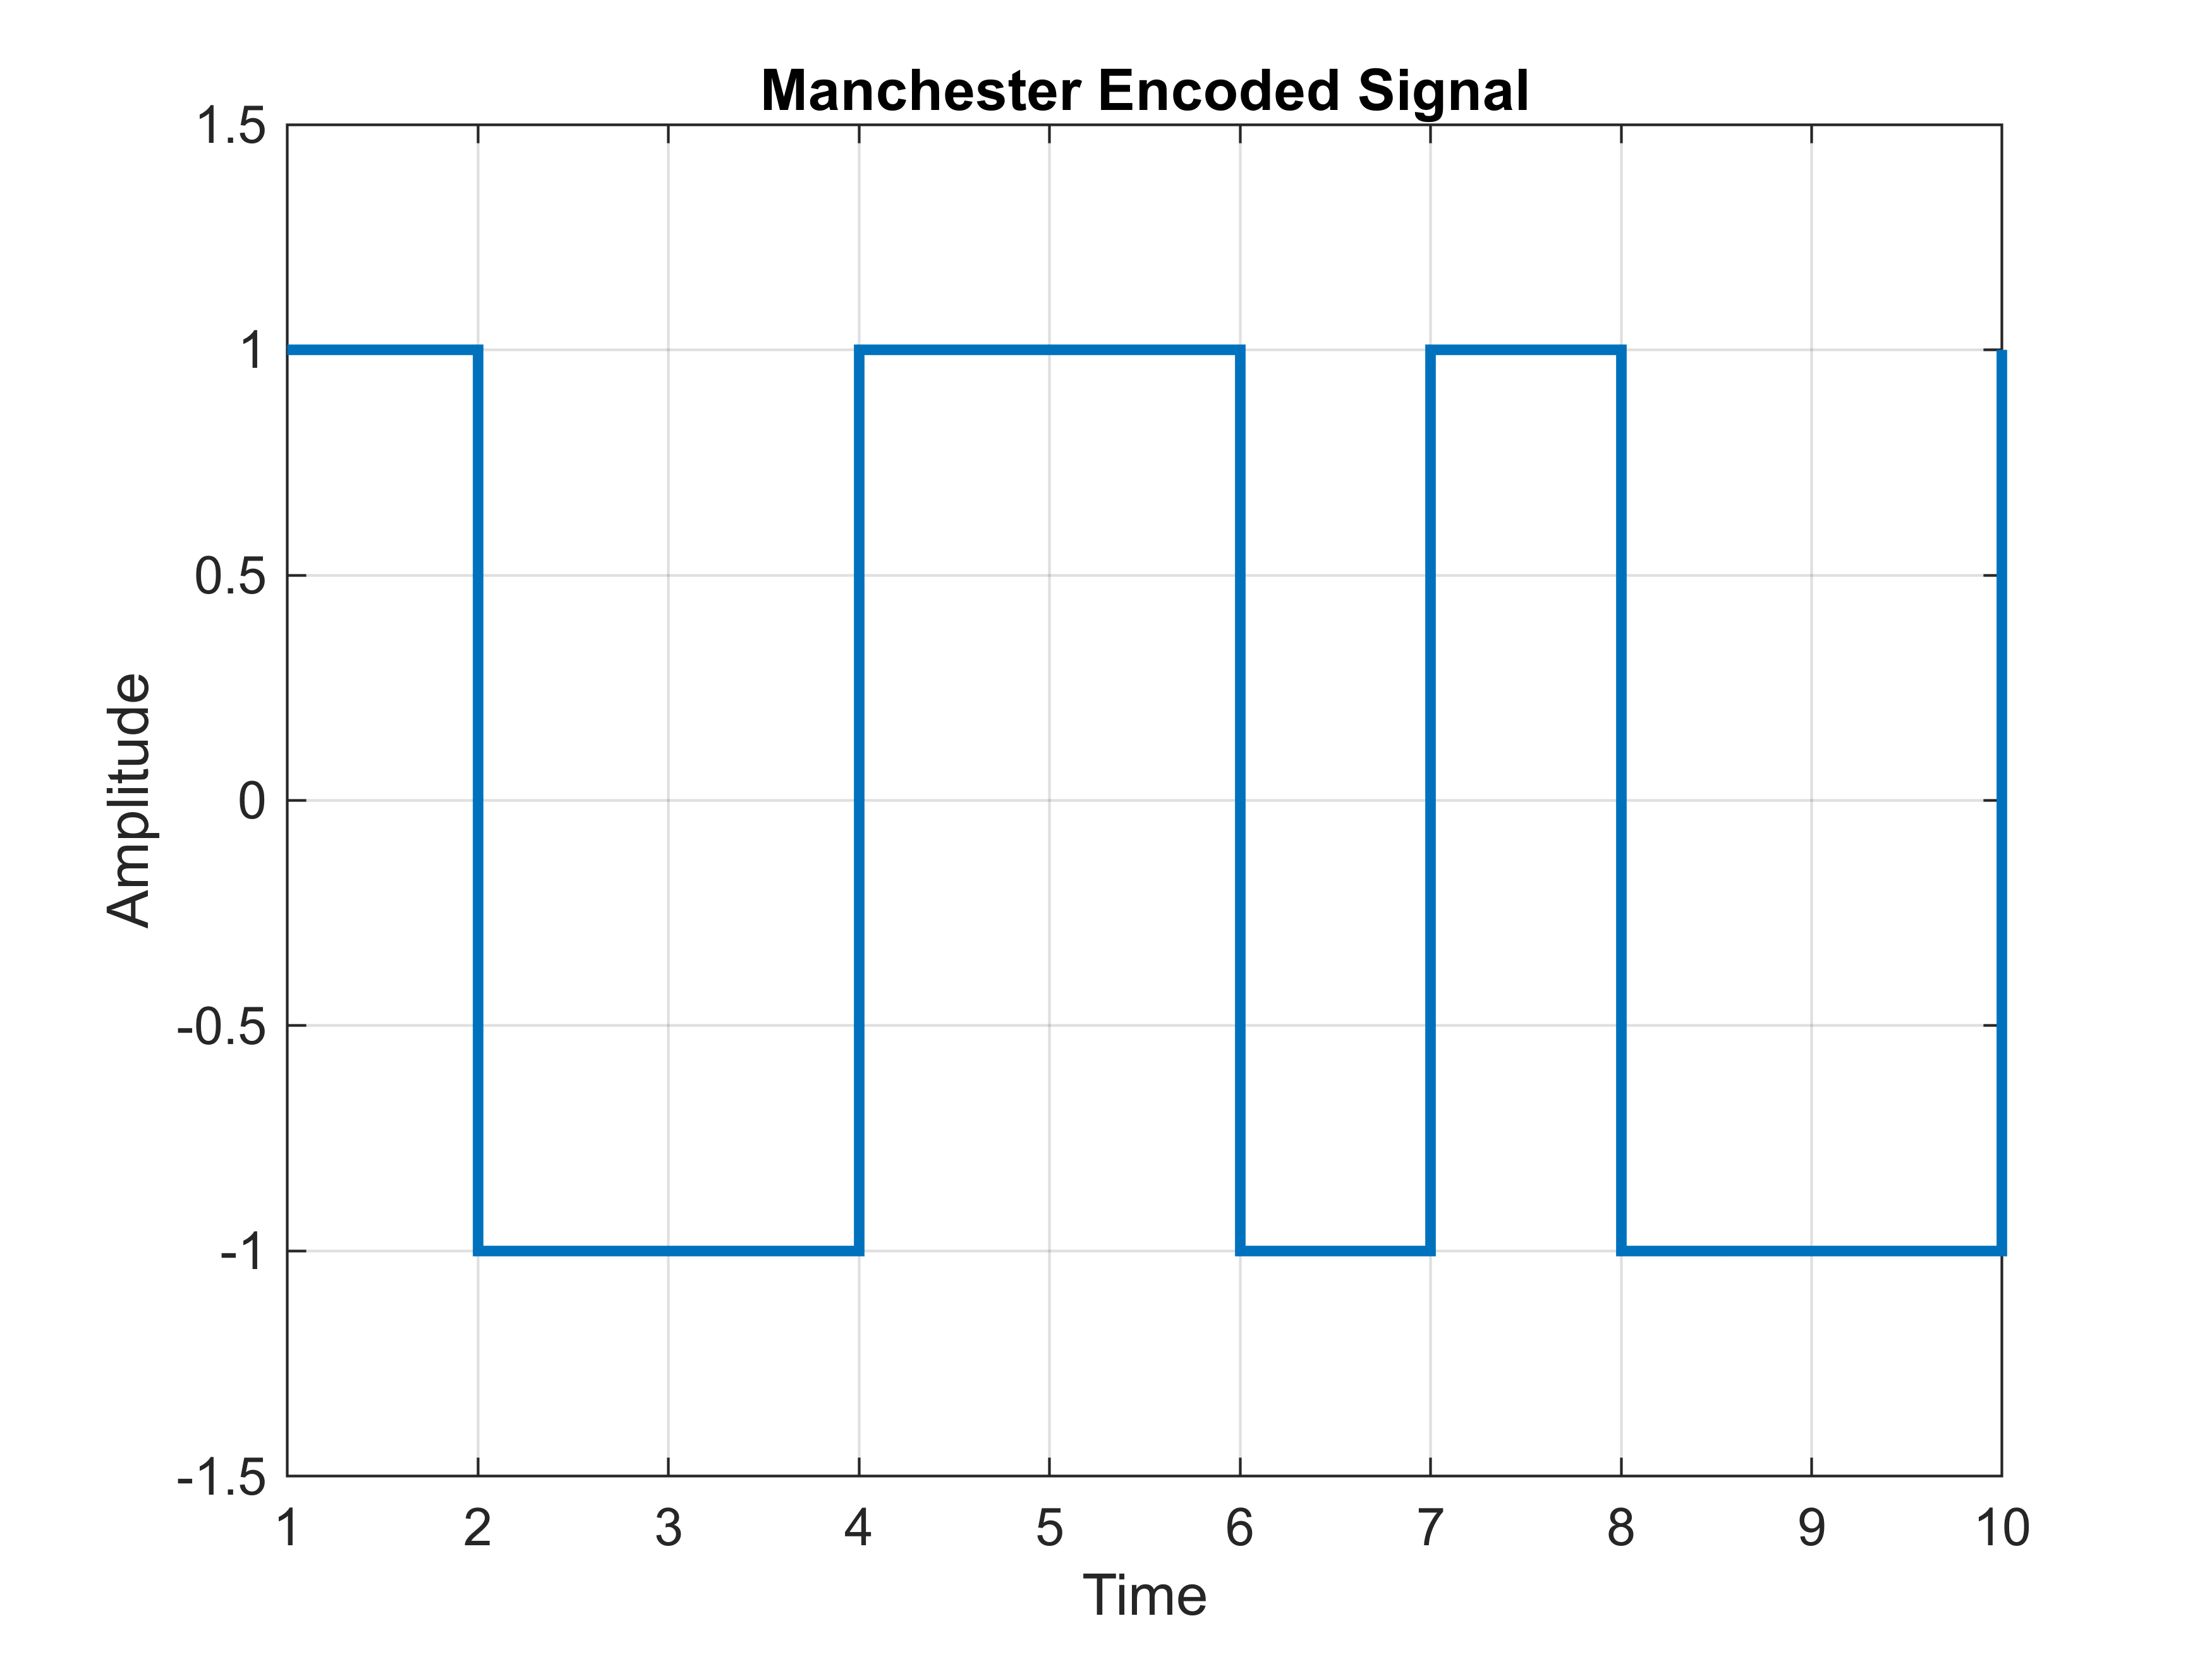

In [7]:
bits = [1 0 1 1 0];

manchester = [];

for i = 1:length(bits)

    if bits(i) == 1
        manchester = [manchester 1 -1];
    else
        manchester = [manchester -1 1];
    end

end

figure;
stairs(manchester, 'LineWidth', 2);
grid on;

xlabel('Time');
ylabel('Amplitude');
title('Manchester Encoded Signal');
ylim([-1.5 1.5]);